Figure S9: eGene colocalization. Number of eGenes colocalized in each credible set group split by whether the group is eQTL only or both a pcQTL and eQTL

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import upsetplot as up
from tqdm.auto import tqdm 
from scipy.stats import spearmanr, linregress, ttest_ind

from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
from matplotlib.patches import Ellipse
import ast
import networkx as nx

tqdm.pandas()

# get outputs from a config file
prefix = '/home/klawren/oak/pcqtls'
import yaml
config_path= f'{prefix}/config_old/main_pcqtl.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

import sys
sys.path.append(f'{config["working_dir"]}/{config["code_dir"]}')
from utils import *
from annotate_clusters import * 
from annotate_null_clusters import * 
from get_pcs import * 


%config InlineBackend.figure_formats = ['png']
# %matplotlib inline
import matplotlib as mpl

plt.rcParams.update({
    'font.size': 8,           # Base font size
    'axes.labelsize': 9,      # Axis labels
    'axes.titlesize': 10,     # Subplot titles
    'xtick.labelsize': 8,     # X-axis tick labels
    'ytick.labelsize': 8,     # Y-axis tick labels
    'legend.fontsize': 8,     # Legend
    'pdf.fonttype': 42,       # Embed fonts in PDF
    'ps.fonttype': 42,        # Embed fonts in PS
})

In [2]:
qtl_signal_groups = load_across_tissues(config, load_qtl_signal_groups)
qtl_signal_groups['exclusive_label'] = np.where((qtl_signal_groups['num_e_coloc'] > 0), np.where((qtl_signal_groups['num_pc_coloc'] > 0), 'Both', 'eQTL only'), 'pcQTL only')

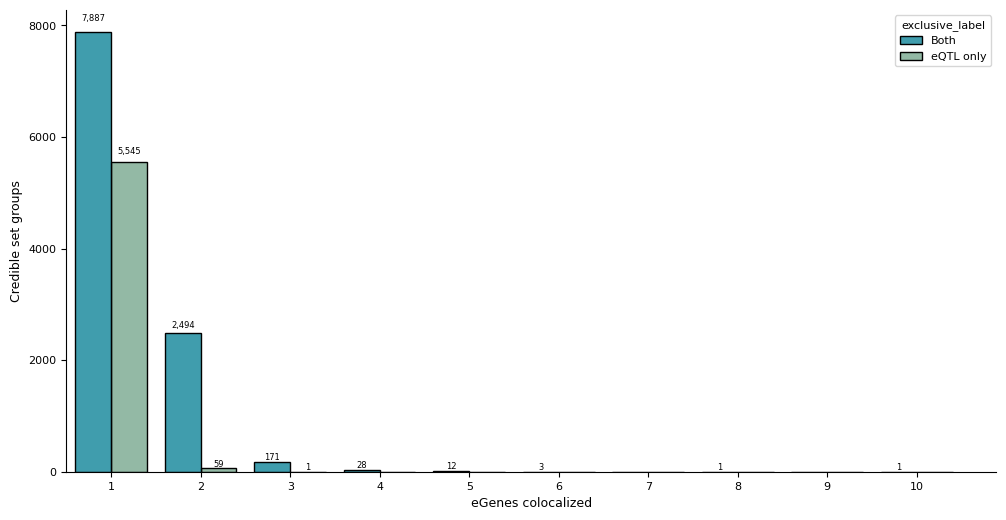

In [3]:
fig, ax = plt.subplots(figsize=(12, 6))
# Create the histogram with split bars
hist_data = qtl_signal_groups[qtl_signal_groups['num_e_coloc'] > 0]
bars = sns.histplot(hist_data, x='num_e_coloc',
                    discrete=True, ax=ax, hue='exclusive_label', multiple='dodge',
                    legend=True, palette=qtl_palette, shrink=0.8)

# Add value labels on bars with better positioning and rotation
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:  # Only add labels for bars with height > 0
            ax.text(bar.get_x() + bar.get_width() / 2., height + height * 0.02,
                    f'{int(height):,}', ha='center', va='bottom', fontsize=6, rotation=0)

ax.spines[['top', 'right']].set_visible(False)
ax.set_xlabel('eGenes colocalized')
ax.set_ylabel('Credible set groups')
ax.set_xticks(range(11))
ax.set_xlim(.5, ax.get_xlim()[1])
ax.set_yticks([0, 2000, 4000, 6000, 8000])
plt.savefig(f"{config['working_dir']}/workflow/supplemental_figures/figures/figure_s7.pdf", 
            transparent=True, bbox_inches='tight', dpi=300)
plt.show()